# Copula Analysis: Tail Dependence Between CDS and DD

Design:
- Variables: CDS and −DD in **levels**
- Pseudo-uniforms computed **within each country** (removing cross-country level differences)
- Pooled within group (Exporter / Control) after within-country ranking
- Fit Gumbel, Clayton, Frank by MLE per group × model (6 fits)
- Primary result: upper tail dependence λ_U from Gumbel
- Expected: M0 exporters ≈ M0 controls; M1/M2 exporters > M1/M2 controls

In [1]:
import numpy as np
import pandas as pd
from scipy.stats import rankdata
from scipy.optimize import minimize_scalar
import matplotlib.pyplot as plt
import matplotlib
import warnings
warnings.filterwarnings('ignore')

matplotlib.rcParams['font.family'] = 'serif'
matplotlib.rcParams['font.serif'] = ['Times New Roman']
matplotlib.rcParams['font.size'] = 8

In [2]:
# ── Paths ──────────────────────────────────────────────────────────────────
GAMMA = 15  # change to 5 or 25 for robustness
RESULTS_PATH = f'../output/Current_results/complete_results_weekly_{GAMMA}_dampening.csv'

DATE_COL    = 'date'
COUNTRY_COL = 'country'
CDS_COL     = 'cds_spread'
DD_COLS     = {'M0': 'DD_M0', 'M1': 'DD_M1', 'M2': 'DD_M2'}

In [3]:
EXPORTERS = ['Saudi Arabia', 'UAE (Abu Dhabi)', 'Colombia', 'Mexico',
             'Brazil', 'Egypt', 'Malaysia', 'Qatar']
CONTROLS  = ['Chile', 'China', 'Indonesia', 'Philippines',
             'South Africa', 'South Korea', 'Thailand', 'Turkey']

In [4]:
df = pd.read_csv(RESULTS_PATH, parse_dates=[DATE_COL])
df = df.sort_values([COUNTRY_COL, DATE_COL]).reset_index(drop=True)
print(df.shape)
print(df.columns.tolist())
df.head(3)

(8352, 26)
['date', 'country', 'cds_spread', 'risk_free_rate', 'B_f', 'LCL_usd', 'sigma_lcl', 'implied_V_M0', 'implied_sigma_V_M0', 'cca_converged_M0', 'implied_V_M1', 'implied_sigma_V_M1', 'cca_converged_M1', 'convenience_yield', 'implied_V_M2', 'implied_sigma_V_M2', 'cca_converged_M2', 'lambda_annual', 'group', 'exporter', 'DD_M0', 'DD_M1', 'DD_M2', 'PD_M0', 'PD_M1', 'PD_M2']


,date,country,cds_spread,risk_free_rate,B_f,LCL_usd,sigma_lcl,implied_V_M0,implied_sigma_V_M0,cca_converged_M0,...,cca_converged_M2,lambda_annual,group,exporter,DD_M0,DD_M1,DD_M2,PD_M0,PD_M1,PD_M2
0,2015-01-04,Brazil,207.97,0.0255,631.8961,792.778598,0.156749,1349.032253,0.092116,True,...,True,8.155143,Exporter,1.0,4.198043,3.634887,3.178353,0.000013,0.000139,0.000741
1,2015-01-11,Brazil,201.92,0.0255,631.8961,812.065172,0.158278,1368.318794,0.093935,True,...,True,7.705558,Exporter,1.0,4.180310,3.529999,3.223647,0.000015,0.000208,0.000633
2,2015-01-18,Brazil,205.65,0.0255,631.8961,814.905830,0.158203,1371.159461,0.094024,True,...,True,8.384939,Exporter,1.0,4.186038,3.612942,3.167098,0.000014,0.000151,0.000770


In [5]:
# ── Within-country pseudo-uniforms ──────────────────────────────────────────
# Rank CDS and -DD within each country's own history, then pool across countries.
# This removes cross-country level differences while preserving within-country
# dependence structure.

def within_country_uniforms(group_countries, model):
    u_all, v_all = [], []
    dd_col = DD_COLS[model]
    for country in group_countries:
        mask = df[COUNTRY_COL] == country
        sub  = df.loc[mask, [CDS_COL, dd_col]].dropna()
        if len(sub) < 10:
            continue
        n = len(sub)
        u = rankdata(sub[CDS_COL].values)  / (n + 1)  # high CDS  = high u
        v = rankdata(-sub[dd_col].values)  / (n + 1)  # low DD    = high v
        u_all.append(u)
        v_all.append(v)
    return np.concatenate(u_all), np.concatenate(v_all)

In [6]:
# ── Sanity check ────────────────────────────────────────────────────────────
for group_name, countries in [('Exporter', EXPORTERS), ('Control', CONTROLS)]:
    u, v = within_country_uniforms(countries, 'M0')
    print(f'{group_name} M0 — N={len(u)}, corr(u,v)={np.corrcoef(u,v)[0,1]:.4f}')

Exporter M0 — N=4176, corr(u,v)=0.4651
Control M0 — N=4176, corr(u,v)=0.0998


In [7]:
# ── Copula log-likelihoods ──────────────────────────────────────────────────

def gumbel_loglik(u, v, theta):
    if theta < 1 + 1e-6:
        return -np.inf
    lu = -np.log(np.clip(u, 1e-10, 1-1e-10))
    lv = -np.log(np.clip(v, 1e-10, 1-1e-10))
    A  = lu**theta + lv**theta
    log_C = -A**(1/theta)
    log_c = (log_C
             + (1/theta - 2) * np.log(A)
             + (theta - 1) * (np.log(lu) + np.log(lv))
             - np.log(u) - np.log(v)
             + np.log(A**(-1/theta) + theta - 1))
    return np.sum(log_c)

def clayton_loglik(u, v, theta):
    if theta < 1e-6:
        return -np.inf
    u = np.clip(u, 1e-10, 1-1e-10)
    v = np.clip(v, 1e-10, 1-1e-10)
    log_c = (np.log(1 + theta)
             - (1 + theta) * np.log(u)
             - (1 + theta) * np.log(v)
             + (-(2 + 1/theta)) * np.log(u**(-theta) + v**(-theta) - 1))
    return np.sum(log_c)

def frank_loglik(u, v, theta):
    if abs(theta) < 1e-6:
        return -np.inf
    u = np.clip(u, 1e-10, 1-1e-10)
    v = np.clip(v, 1e-10, 1-1e-10)
    et  = np.exp(-theta)
    etu = np.exp(-theta * u)
    etv = np.exp(-theta * v)
    num = theta * (et - 1) * np.exp(-theta * (u + v))
    den = ((et - 1) + (etu - 1) * (etv - 1))**2
    log_c = np.log(np.clip(num / den, 1e-300, None))
    return np.sum(log_c)

In [8]:
# ── Fitting ─────────────────────────────────────────────────────────────────

def fit_gumbel(u, v):
    res   = minimize_scalar(lambda th: -gumbel_loglik(u, v, th),
                            bounds=(1.001, 20), method='bounded')
    theta = res.x
    ll    = -res.fun
    aic   = -2*ll + 2
    tail  = 2 - 2**(1/theta)
    return dict(family='Gumbel', theta=theta, loglik=ll, AIC=aic, tail_dep=tail)

def fit_clayton(u, v):
    res   = minimize_scalar(lambda th: -clayton_loglik(u, v, th),
                            bounds=(0.001, 30), method='bounded')
    theta = res.x
    ll    = -res.fun
    aic   = -2*ll + 2
    tail  = 2**(-1/theta)
    return dict(family='Clayton', theta=theta, loglik=ll, AIC=aic, tail_dep=tail)

def fit_frank(u, v):
    res   = minimize_scalar(lambda th: -frank_loglik(u, v, th),
                            bounds=(0.01, 30), method='bounded')
    theta = res.x
    ll    = -res.fun
    aic   = -2*ll + 2
    return dict(family='Frank', theta=theta, loglik=ll, AIC=aic, tail_dep=0.0)

def fit_all(u, v):
    g = fit_gumbel(u, v)
    c = fit_clayton(u, v)
    f = fit_frank(u, v)
    best_aic = min(g['AIC'], c['AIC'], f['AIC'])
    for d in [g, c, f]:
        d['best'] = (d['AIC'] == best_aic)
    return g, c, f

In [9]:
# ── Run: 2 groups × 3 models ────────────────────────────────────────────────
groups = {'Exporter': EXPORTERS, 'Control': CONTROLS}
models = ['M0', 'M1', 'M2']

results    = []
fits_store = {}

for group_name, countries in groups.items():
    for model in models:
        u, v = within_country_uniforms(countries, model)
        g, c, f = fit_all(u, v)
        fits_store[(group_name, model)] = (u, v, g)
        for cop in [g, c, f]:
            results.append({
                'Group':    group_name,
                'Model':    model,
                'Copula':   cop['family'],
                'theta':    cop['theta'],
                'LogLik':   cop['loglik'],
                'AIC':      cop['AIC'],
                'tail_dep': cop['tail_dep'],
                'Best_AIC': cop['best'],
                'N':        len(u)
            })

res_df = pd.DataFrame(results)

In [10]:
# ── AIC comparison ──────────────────────────────────────────────────────────
aic_pivot = res_df.pivot_table(index=['Group','Model'], columns='Copula', values='AIC').round(1)
aic_pivot['Best'] = aic_pivot.idxmin(axis=1)
print('AIC by family:')
print(aic_pivot.to_string())

AIC by family:
Copula          Clayton      Frank  Gumbel     Best
Group    Model                                     
Control  M0       -20.5  5769359.2  3523.3  Clayton
         M1      -108.7  5769359.2  2388.1  Clayton
         M2      -186.5  5769359.2  1450.9  Clayton
Exporter M0      -710.7  5769359.2   549.7  Clayton
         M1      -864.7  5769359.2  -683.3  Clayton
         M2     -1272.6  5769359.2 -1142.2  Clayton


In [11]:
# ── Key result table ────────────────────────────────────────────────────────
gumbel_df = res_df[res_df['Copula'] == 'Gumbel'][['Group','Model','theta','tail_dep','AIC','Best_AIC']].copy()
pivot = gumbel_df.pivot(index='Group', columns='Model', values='tail_dep')[['M0','M1','M2']]
pivot['M1-M0'] = pivot['M1'] - pivot['M0']
pivot['M2-M0'] = pivot['M2'] - pivot['M0']

print('Gumbel upper tail dependence λ_U = 2 − 2^(1/θ)')
print(pivot.round(3).to_string())
print()
print('Exporter minus Control differential:')
print((pivot.loc['Exporter'] - pivot.loc['Control']).round(3))

Gumbel upper tail dependence λ_U = 2 − 2^(1/θ)
Model        M0     M1     M2  M1-M0  M2-M0
Group                                      
Control   0.411  0.452  0.474  0.041  0.063
Exporter  0.511  0.549  0.563  0.038  0.052

Exporter minus Control differential:
Model
M0       0.100
M1       0.097
M2       0.089
M1-M0   -0.003
M2-M0   -0.011
dtype: float64


FileNotFoundError: [Errno 2] No such file or directory: '../output/figures/graph_copulas.pdf'

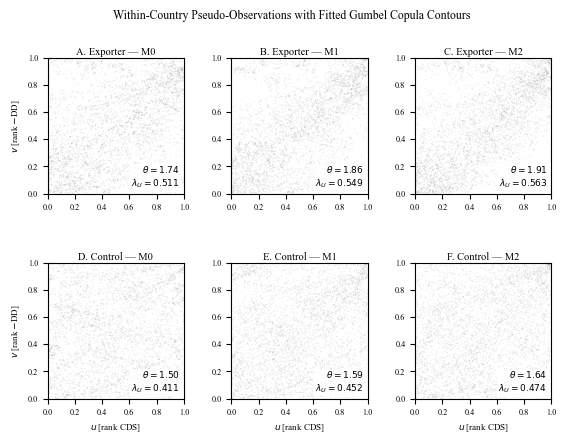

In [12]:
# ── Figure ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(6.5, 4.5))
plt.subplots_adjust(hspace=0.45, wspace=0.35)

panel_labels = [['A','B','C'],['D','E','F']]
cmaps = {'Exporter': 'Blues', 'Control': 'Oranges'}

def gumbel_cdf(u, v, theta):
    lu = -np.log(np.clip(u, 1e-10, 1-1e-10))
    lv = -np.log(np.clip(v, 1e-10, 1-1e-10))
    return np.exp(-(lu**theta + lv**theta)**(1/theta))

def gumbel_density_grid(theta, n=150):
    eps = 1e-3
    g = np.linspace(eps, 1-eps, n)
    U, V = np.meshgrid(g, g)
    h = 1e-5
    C   = gumbel_cdf(U,   V,   theta)
    Cup = gumbel_cdf(U+h, V+h, theta)
    Cu  = gumbel_cdf(U+h, V,   theta)
    Cv  = gumbel_cdf(U,   V+h, theta)
    dens = np.clip((Cup - Cu - Cv + C) / h**2, 0, None)
    return U, V, dens

for i, (group_name, _) in enumerate(groups.items()):
    for j, model in enumerate(models):
        ax = axes[i, j]
        u, v, gfit = fits_store[(group_name, model)]

        ax.scatter(u, v, s=0.8, c='black', alpha=0.08, edgecolors='none', zorder=1)

        U, V, Z = gumbel_density_grid(gfit['theta'])
        ax.contour(U, V, Z, levels=7, cmap=cmaps[group_name],
                   linewidths=0.9, alpha=0.85, zorder=2)

        label = panel_labels[i][j]
        ax.set_title(f'{label}. {group_name} — {model}', fontsize=7.5, pad=2)
        ax.text(0.97, 0.03,
                f'$\\theta={gfit["theta"]:.2f}$\n$\\lambda_U={gfit["tail_dep"]:.3f}$',
                transform=ax.transAxes, fontsize=6.5, va='bottom', ha='right',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                          edgecolor='none', alpha=0.8))

        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.set_aspect('equal')
        ax.tick_params(axis='both', labelsize=6)
        if i == 1:
            ax.set_xlabel(r'$u$ [rank CDS]', fontsize=6.5)
        if j == 0:
            ax.set_ylabel(r'$v$ [rank $-$DD]', fontsize=6.5)

fig.suptitle('Within-Country Pseudo-Observations with Fitted Gumbel Copula Contours',
             fontsize=8.5, fontweight='normal')
plt.savefig('../output/figures/graph_copulas.pdf', bbox_inches='tight', dpi=200)
plt.savefig('../output/figures/graph_copulas.png', bbox_inches='tight', dpi=200)
plt.show()
print('Done')

In [ ]:
# ── LaTeX table ─────────────────────────────────────────────────────────────
rows = []
for _, row in gumbel_df.sort_values(['Group','Model']).iterrows():
    best = r'$^{*}$' if row['Best_AIC'] else ''
    rows.append(
        f"{row['Group']} & {row['Model']} & {row['theta']:.3f} "
        f"& {row['tail_dep']:.3f} & {row['AIC']:.1f}{best} \\\\"
    )

print(r"""\begin{table}[htbp]
\centering
\begin{tcolorbox}[
    colback=black!3, colframe=black!40, boxrule=0.4pt, arc=2pt,
    left=8pt, right=8pt, top=6pt, bottom=6pt, width=\textwidth]
\footnotesize
\begin{center}\textbf{Table X.} Gumbel Copula Fits: Upper Tail Dependence.\end{center}
\vspace{4pt}\hrule\vspace{6pt}
\begin{tabular*}{\textwidth}{@{\extracolsep{\fill}} llccc}
\toprule
Group & Model & $\\theta$ & $\\lambda_U$ & AIC \\\\
\\midrule""")
for r in rows:
    print(r)
print(r"""\bottomrule
\end{tabular*}
\vspace{6pt}\hrule\vspace{4pt}
\footnotesize
\textit{Note:} Gumbel copulas fitted by MLE to pseudo-uniform pairs $(u,v)$
computed within each country's own time series, then pooled across countries
within each group. $u = \\text{rank}(\\text{CDS})$, $v = \\text{rank}(-\\text{DD})$.
$\\lambda_U = 2 - 2^{1/\\theta}$ is the upper tail dependence coefficient.
$^{*}$ preferred by AIC among Gumbel, Clayton, Frank.
\end{tcolorbox}
\caption{Gumbel copula parameter estimates and upper tail dependence by group and model.}
\label{tab:copula_gumbel}
\end{table}""")